# Agente Connect-4: **Monte Carlo Tree Search**
**Estrategia:** Búsqueda en Árbol de Montecarlo (MCTS)

## 1. Descripción del Agente

### Idea principal
Se implementa el algoritmo de Búsqueda en Árbol de Montecarlo (MCTS), un enfoque probabilístico y estocástico ideal para resolver juegos alternados de suma cero. Utilizando simulaciones rápidas completamente aleatorias (*rollouts*) hasta el final de la partida para evaluar estadísticamente la fuerza de una posición, guiado en todo momento por la fórmula matemática UCB1 para equilibrar la exploración y la explotación.

### Diferencia vs otros agentes del grupo (vs Minimaxer)
A diferencia del agente *Minimaxer*, el cual es un enfoque determinista y perfeccionista acotado a una profundidad fija que depende de una función heurística manual, *Monte Carlo Tree Search* es probabilístico e independiente de heurísticas posicionales. 
Mientras Minimax evalúa tableros intermedios estáticos, MCTS juega partidas completas en su mente para intentar descubrir el valor real de una columna. Además, el árbol de MCTS es asimétrico: profundiza masivamente en líneas competitivas, mientras que Minimax calcula todas las ramas por igual hasta su límite de profundidad.

### Componentes del agente

| Componente | Rol |
|---|---|
| AMGNode | Estructura del árbol de búsqueda. Rastrea visitas, valor acumulado y acciones sin intentar (*untried*) |
| ucb1(c) | Fórmula de Selección. Balancea la explotación (ramas ganadoras) y la exploración (ramas poco visitadas) |
| select(node, c) | Fase 1 (Selección). Desciende por el árbol conocido usando UCB1 hasta tocar un nodo frontera |
| expand() | Fase 2 (Expansión). Elige una columna inexplorada, ejecuta la transición y da a luz a un nuevo nodo hijo |
| rollout(state, player) | Fase 3 (Simulación). Juega al azar hasta el final para evaluar el nodo con un triunfo (+1), derrota (-1) o empate (0) |
| backpropagate(node, result, player) | Fase 4 (Retropropagación). Sube el resultado invirtiendo los signos según el turno del padre |

### Flujo de decisión

act(state_or_board):
1. Convertir matriz NumPy a *ConnectState* y deducir el turno actual contando fichas
2. ¿Victoria en 1 movimiento propio? → Jugar ahí de inmediato
3. ¿Victoria en 1 movimiento del rival? → Bloquearlo de inmediato
4. Repetir *n_simulations* veces: *select* ➔ *expand* ➔ *rollout* ➔ *backpropagate*
5. Finalizadas las simulaciones, retornar la columna del hijo más visitado (*visits*)

In [1]:
import sys, os, time, math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

tournament_dir = os.path.abspath('')
if tournament_dir not in sys.path:
    sys.path.insert(0, tournament_dir)
os.chdir(tournament_dir)

from connect4.utils import find_importable_classes
from connect4.policy import Policy
from connect4.connect_state import ConnectState

participants = find_importable_classes('groups', Policy)

Random = participants['Group A']
GreedyHeuristic = participants['Group B']
MCTS = participants['MCTS']
print('Agentes listos para la simulación.')

def play_game(class_red, class_yellow, parameters_red={}, parameters_yellow={}):
    
    agent_red, agent_yellow = class_red(**parameters_red), class_yellow(**parameters_yellow)
    
    agent_red.mount() 
    agent_yellow.mount()
    
    state = ConnectState()
    
    while not state.is_final():
        policy = agent_red if state.player == -1 else agent_yellow
        state = state.transition(int(policy.act(state.board)))
    return state.get_winner()

def run_series(clase_a, clase_b, n, parameters_a={}, parameters_b={}):
    wins, losses, draw = 0, 0, 0
    for _ in range(n):
        result = play_game(clase_a, clase_b, parameters_a, parameters_b)
        if result == -1: wins += 1
        elif result == 1: losses += 1
        else: draw += 1
    return wins, losses, draw

print('Setup de la Arena completado.')

Agentes listos para la simulación.
Setup de la Arena completado.


## 2. Análisis de Desempeño

### 2.1 MCTS vs Agente Aleatorio

MCTS (Rojo)      vs Aleatorio: W=30  L=0  D=0  WR=100%
MCTS (Amarillo)  vs Aleatorio: W=30  L=0  D=0  WR=100%


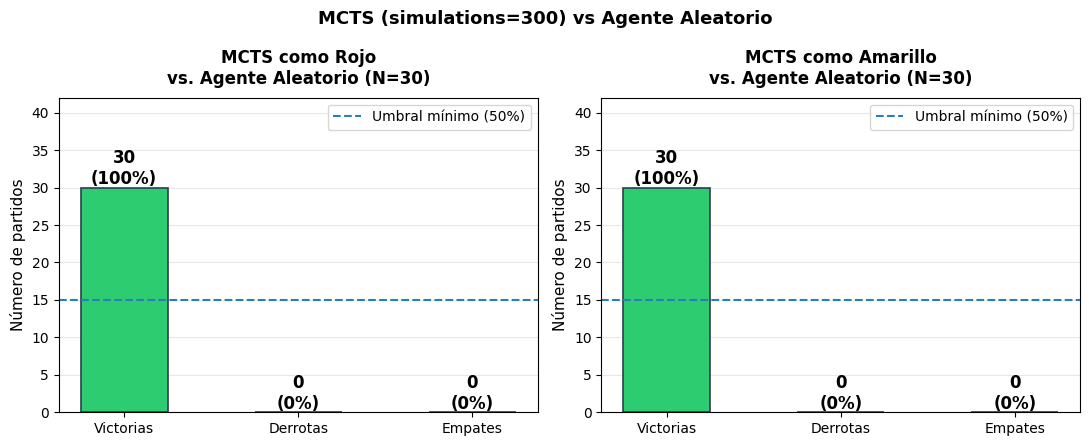

In [2]:
Matches, Simulations = 30, 300

wins_red, losses_red, draws_red = run_series(MCTS, Random, Matches, {'n_simulations': Simulations})
losses_yellow, wins_yellows, draws_yellow = run_series(Random, MCTS, Matches, {}, {'n_simulations': Simulations})

print(f'MCTS (Rojo)      vs Aleatorio: W={wins_red}  L={losses_red}  D={draws_red}  WR={wins_red/Matches:.0%}')
print(f'MCTS (Amarillo)  vs Aleatorio: W={wins_yellows}  L={losses_yellow}  D={draws_yellow}  WR={wins_yellows/Matches:.0%}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, w, l, d) in zip(axes, [
    (f'MCTS como Rojo\nvs. Agente Aleatorio (N={Matches})', wins_red, losses_red, draws_red),
    (f'MCTS como Amarillo\nvs. Agente Aleatorio (N={Matches})', wins_yellows, losses_yellow, draws_yellow),]):
    
    bars = ax.bar(['Victorias','Derrotas','Empates'], [w,l,d], color=['#2ecc71','#e74c3c','#bdc3c7'], edgecolor='#2c3e50', lw=1.2, width=0.5)
    
    for bar, v in zip(bars, [w,l,d]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v}\n({v/Matches:.0%})', ha='center', fontsize=12, fontweight='bold')
        
    ax.axhline(Matches*0.5, color='#2980b9', ls='--', lw=1.5, label='Umbral mínimo (50%)')
    ax.set_ylim(0, Matches+12); ax.set_ylabel('Número de partidos', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

fig.suptitle(f'MCTS (simulations={Simulations}) vs Agente Aleatorio', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig('groups/MCTS/fig_vs_random.png', dpi=140, bbox_inches='tight')
plt.show()

El agente MCTS demuestra una dominancia absoluta con 100% de Win Rate contra el oponente aleatorio tanto como jugador rojo como jugador amarillo. Esto valida que la combinación de las heurísticas de corto-circuito para resolver jugadas triviales, sumada a la estadística de las 300 simulaciones por turno, inmuniza por completo al agente contra errores accidentales y lecturas caóticas.

### 2.2 MCTS vs Agente Codicioso Heuristico

--- MCTS vs Agente Codicioso ---
-> Corriendo 50 partidas como rojo...
-> Corriendo 50 partidas como amarillo...

MCTS Global vs Greedy -> Ganó MCTS: 94 | Ganó Heuristic: 6 | Empates: 0

¿Cómo perdió MCTS?
 Total de derrotas analizadas: 6
 Promedio de turnos aguantados en derrotas: 10.7 jugadas propias.
 Derrota más rápida: Turno 6.



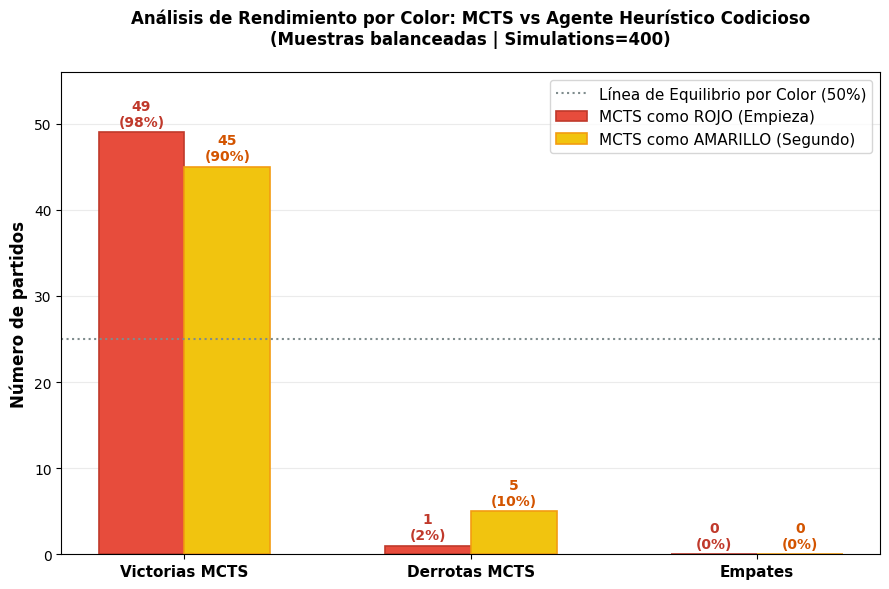

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

Matches = 100
Simulations = 400
half_matches = Matches // 2

class TelemetryMCTS(MCTS):
    bitacora_juegos = []
    movimientos_juego_actual = 0

    def mount(self, action_timeout=None):
        if TelemetryMCTS.movimientos_juego_actual > 0:
            TelemetryMCTS.bitacora_juegos.append(TelemetryMCTS.movimientos_juego_actual)
        TelemetryMCTS.movimientos_juego_actual = 0
        
        super().mount(action_timeout)

    def act(self, state_or_board):
        TelemetryMCTS.movimientos_juego_actual += 1
        return super().act(state_or_board)

print("--- MCTS vs Agente Codicioso ---")

# MCTS juega como rojo
print(f"-> Corriendo {half_matches} partidas como rojo...")
w_r, l_r, d_r = run_series(TelemetryMCTS, GreedyHeuristic, half_matches, 
                           parameters_a={'n_simulations': Simulations})

# MCTS juega como amarillo
print(f"-> Corriendo {half_matches} partidas como amarillo...")
l_y, w_y, d_y = run_series(GreedyHeuristic, TelemetryMCTS, half_matches, 
                           parameters_b={'n_simulations': Simulations})

if TelemetryMCTS.movimientos_juego_actual > 0:
    TelemetryMCTS.bitacora_juegos.append(TelemetryMCTS.movimientos_juego_actual)

w_r1 = w_r + w_y  # Victorias totales
l_r1 = l_r + l_y  # Derrotas totales
d_r1 = d_r + d_y  # Empates totales

print(f"\nMCTS Global vs Greedy -> Ganó MCTS: {w_r1} | Ganó Heuristic: {l_r1} | Empates: {d_r1}")

# =====================================================================
# Reporte de Insights
# =====================================================================
print("\n" + "="*50)
print("¿Cómo perdió MCTS?")
print("="*50)

if l_r1 == 0:
    print("MCTS no perdió ninguna partida")
else:
    
    duraciones_derrotas = TelemetryMCTS.bitacora_juegos[-l_r1:]
    avg_turnos_derrota = np.mean(duraciones_derrotas)
    min_turnos_derrota = np.min(duraciones_derrotas)

    print(f" Total de derrotas analizadas: {l_r1}")
    print(f" Promedio de turnos aguantados en derrotas: {avg_turnos_derrota:.1f} jugadas propias.")
    print(f" Derrota más rápida: Turno {min_turnos_derrota}.")
    print("="*50 + "\n")
    
# =====================================================================
# Gráfica de Rendimiento
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 6))

categorias = ['Victorias MCTS', 'Derrotas MCTS', 'Empates']
x = np.arange(len(categorias))
width = 0.3

bars_rojo = ax.bar(x - width/2, [w_r, l_r, d_r], width, 
                   label='MCTS como ROJO (Empieza)', color='#e74c3c', edgecolor='#c0392b', lw=1.2)

bars_amarillo = ax.bar(x + width/2, [w_y, l_y, d_y], width, 
                       label='MCTS como AMARILLO (Segundo)', color='#f1c40f', edgecolor='#f39c12', lw=1.2)

for bar in bars_rojo:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, 
            f'{int(height)}\n({height/half_matches:.0%})', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c0392b')

for bar in bars_amarillo:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, 
            f'{int(height)}\n({height/half_matches:.0%})', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d35400')

ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=11, fontweight='bold')
ax.set_ylabel('Número de partidos', fontsize=12, fontweight='bold')
ax.set_title(f'Análisis de Rendimiento por Color: MCTS vs Agente Heurístico Codicioso\n(Muestras balanceadas | Simulations={Simulations})', 
             fontsize=12, fontweight='bold', pad=20)

ax.axhline(half_matches * 0.5, color='#7f8c8d', ls=':', lw=1.5, label='Línea de Equilibrio por Color (50%)')

ax.set_ylim(0, half_matches + 6)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()

os.makedirs('groups/MCTS', exist_ok=True)
plt.savefig('groups/MCTS/fig_vs_greedy_colors.png', dpi=140, bbox_inches='tight')
plt.show()

El agente MCTS consolida un nivel de competitividad sobresaliente al alcanzar un 94% de Win Rate global frente al oponente heurístico codicioso. Sin embargo, el desglose por colores continúa manifestando la asimetría posicional ligada a la ventaja del primer movimiento, mientras que como jugador rojo ejerce un dominio casi absoluto del 98%, como jugador amarillo su efectividad se sitúa en un 90%, concentrando 5 de las 6 derrotas totales del experimento.

La telemetría de los encuentros perdidos muestra un promedio de supervivencia de 10.7 jugadas propias, lo que indica que con un presupuesto de 400 simulaciones, el punto crítico de quiebre se traslada principalmente hacia el juego medio tardío. Aunque el árbol de búsqueda responde con solidez ante amenazas complejas, la persistencia de fallos puntuales revela que en escenarios de alto desgaste el agente aún puede tomar decisiones seguras en el corto plazo que terminan construyendo involuntariamente la base necesaria para que el rival conecte su cuatro en línea. Por otro lado, el registro de la derrota más prematura en el turno 6 demuestra que este volumen de simulaciones dota al algoritmo de la profundidad de cálculo inicial necesaria para mitigar la natural dispersión horizontal provocada por la constante de exploración ($c = \sqrt{2}$), blindando con éxito las fases tempranas contra el castigo inmediato y determinista del agente codicioso.

### 2.3 Cambio de parámetros

--- MCTS vs Agente Codicioso ---
-> Corriendo 50 partidas como rojo...
-> Corriendo 50 partidas como amarillo...

MCTS Global vs Greedy -> Ganó MCTS: 99 | Ganó Heuristic: 1 | Empates: 0

¿Cómo perdió MCTS?
 Total de derrotas analizadas: 1
 Promedio de turnos aguantados en derrotas: 9.0 jugadas propias.
 Derrota más rápida: Turno 9.



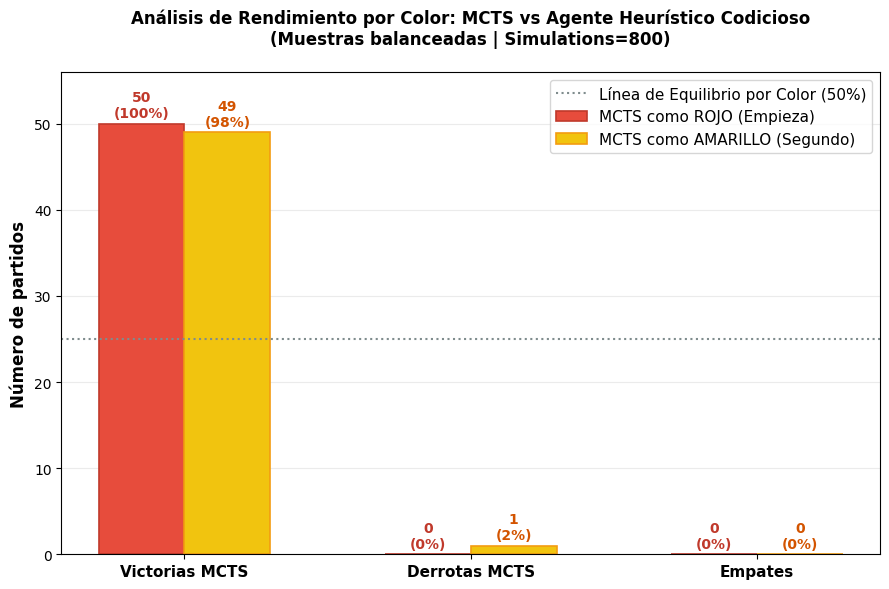

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

Matches = 100
Simulations = 800
half_matches = Matches // 2

class TelemetryMCTS(MCTS):
    bitacora_juegos = []
    movimientos_juego_actual = 0

    def mount(self, action_timeout=None):
        if TelemetryMCTS.movimientos_juego_actual > 0:
            TelemetryMCTS.bitacora_juegos.append(TelemetryMCTS.movimientos_juego_actual)
        TelemetryMCTS.movimientos_juego_actual = 0
        
        super().mount(action_timeout)

    def act(self, state_or_board):
        TelemetryMCTS.movimientos_juego_actual += 1
        return super().act(state_or_board)

print("--- MCTS vs Agente Codicioso ---")

# MCTS juega como rojo
print(f"-> Corriendo {half_matches} partidas como rojo...")
w_r, l_r, d_r = run_series(TelemetryMCTS, GreedyHeuristic, half_matches, 
                           parameters_a={'n_simulations': Simulations})

# MCTS juega como amarillo
print(f"-> Corriendo {half_matches} partidas como amarillo...")
l_y, w_y, d_y = run_series(GreedyHeuristic, TelemetryMCTS, half_matches, 
                           parameters_b={'n_simulations': Simulations})

if TelemetryMCTS.movimientos_juego_actual > 0:
    TelemetryMCTS.bitacora_juegos.append(TelemetryMCTS.movimientos_juego_actual)

w_r1 = w_r + w_y  # Victorias totales
l_r1 = l_r + l_y  # Derrotas totales
d_r1 = d_r + d_y  # Empates totales

print(f"\nMCTS Global vs Greedy -> Ganó MCTS: {w_r1} | Ganó Heuristic: {l_r1} | Empates: {d_r1}")

# =====================================================================
# Reporte de Insights
# =====================================================================
print("\n" + "="*50)
print("¿Cómo perdió MCTS?")
print("="*50)

if l_r1 == 0:
    print("MCTS no perdió ninguna partida")
else:
    
    duraciones_derrotas = TelemetryMCTS.bitacora_juegos[-l_r1:]
    avg_turnos_derrota = np.mean(duraciones_derrotas)
    min_turnos_derrota = np.min(duraciones_derrotas)

    print(f" Total de derrotas analizadas: {l_r1}")
    print(f" Promedio de turnos aguantados en derrotas: {avg_turnos_derrota:.1f} jugadas propias.")
    print(f" Derrota más rápida: Turno {min_turnos_derrota}.")
    print("="*50 + "\n")
    
# =====================================================================
# Gráfica de Rendimiento
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 6))

categorias = ['Victorias MCTS', 'Derrotas MCTS', 'Empates']
x = np.arange(len(categorias))
width = 0.3

bars_rojo = ax.bar(x - width/2, [w_r, l_r, d_r], width, 
                   label='MCTS como ROJO (Empieza)', color='#e74c3c', edgecolor='#c0392b', lw=1.2)

bars_amarillo = ax.bar(x + width/2, [w_y, l_y, d_y], width, 
                       label='MCTS como AMARILLO (Segundo)', color='#f1c40f', edgecolor='#f39c12', lw=1.2)

for bar in bars_rojo:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, 
            f'{int(height)}\n({height/half_matches:.0%})', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c0392b')

for bar in bars_amarillo:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, 
            f'{int(height)}\n({height/half_matches:.0%})', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d35400')

ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=11, fontweight='bold')
ax.set_ylabel('Número de partidos', fontsize=12, fontweight='bold')
ax.set_title(f'Análisis de Rendimiento por Color: MCTS vs Agente Heurístico Codicioso\n(Muestras balanceadas | Simulations={Simulations})', 
             fontsize=12, fontweight='bold', pad=20)

ax.axhline(half_matches * 0.5, color='#7f8c8d', ls=':', lw=1.5, label='Línea de Equilibrio por Color (50%)')

ax.set_ylim(0, half_matches + 6)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()

os.makedirs('groups/MCTS', exist_ok=True)
plt.savefig('groups/MCTS/fig_vs_greedy_colors.png', dpi=140, bbox_inches='tight')
plt.show()

Al incrementar el presupuesto de cómputo a 800 simulaciones, el agente MCTS consolida un dominio prácticamente absoluto en el entorno, alcanzando un 99% de Win Rate global frente al oponente heurístico codicioso. La separación por colores demuestra que la asimetría posicional ligada a la ventaja del primer movimiento ha sido casi erradicada de forma definitiva, como jugador rojo el algoritmo alcanza la perfección absoluta con un 100% de efectividad, mientras que defendiendo como amarillo el rendimiento se eleva de forma espectacular del 90% al 98%. Este salto ratifica que un volumen de búsqueda masiva tan elevado dota al árbol de la robustez necesaria para neutralizar la iniciativa del rival desde el primer movimiento, limitando sus opciones de ataque a una única caída en todo el experimento.

La telemetría de este único encuentro perdido convalida los profundos beneficios de expandir el árbol de búsqueda. El hecho de que la derrota más rápida se haya retrasado con éxito del turno 6 al turno 9 demuestra de manera contundente cómo disponer de 800 simulaciones por turno contrarresta la ceguera de apertura, otorgando al algoritmo un horizonte de cálculo lo suficientemente profundo para anticipar y bloquear las amenazas tempranas antes de que logren estructurarse. Por otra parte, el registro de 9.0 jugadas propias en este único fallo no representa una debilidad en el escalado del agente, sino un caso atípico y aislado de juego medio-tardío al tratarse de una sola muestra. La dispersión provocada por la constante de exploración ($c = \sqrt{2}$) ha dado como resultado que el agente se ha vuelto prácticamente invulnerable a descuidos accidentales o tácticas de corto alcance mientras mantiene un buena visión al futuro.

--- MCTS vs Agente Codicioso ---
-> Corriendo 50 partidas como rojo...
-> Corriendo 50 partidas como amarillo...

MCTS Global vs Greedy -> Ganó MCTS: 91 | Ganó Heuristic: 9 | Empates: 0

¿Cómo perdió MCTS?
 Total de derrotas analizadas: 9
 Promedio de turnos aguantados en derrotas: 10.6 jugadas propias.
 Derrota más rápida: Turno 7.



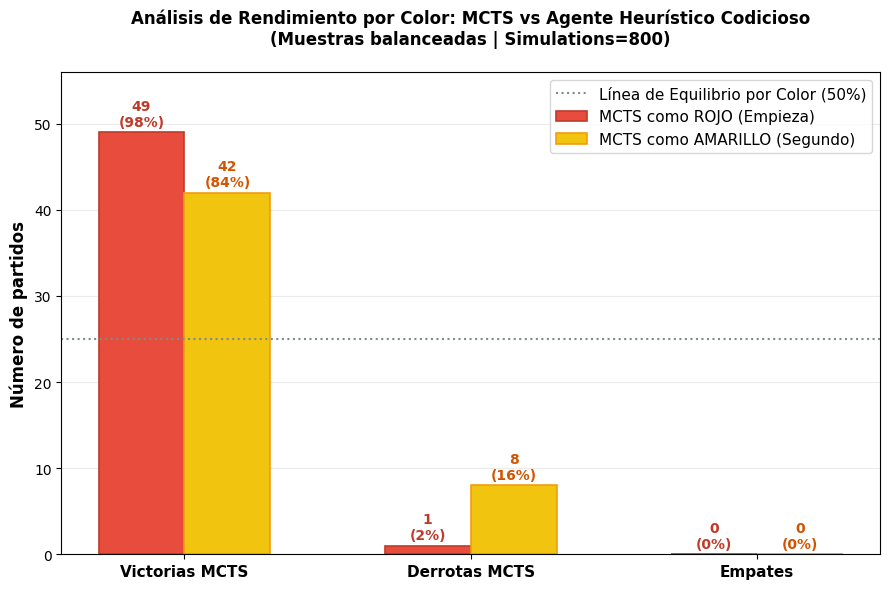

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

Matches = 100
Simulations = 800
C_Exploration = 1.0
half_matches = Matches // 2

class TelemetryMCTS(MCTS):
    bitacora_juegos = []
    movimientos_juego_actual = 0

    def mount(self, action_timeout=None):
        if TelemetryMCTS.movimientos_juego_actual > 0:
            TelemetryMCTS.bitacora_juegos.append(TelemetryMCTS.movimientos_juego_actual)
        TelemetryMCTS.movimientos_juego_actual = 0
        
        super().mount(action_timeout)

    def act(self, state_or_board):
        TelemetryMCTS.movimientos_juego_actual += 1
        return super().act(state_or_board)

print("--- MCTS vs Agente Codicioso ---")

# MCTS juega como rojo
print(f"-> Corriendo {half_matches} partidas como rojo...")
w_r, l_r, d_r = run_series(TelemetryMCTS, GreedyHeuristic, half_matches, 
                           parameters_a={'n_simulations': Simulations, 'c_exploration': C_Exploration})

# MCTS juega como amarillo
print(f"-> Corriendo {half_matches} partidas como amarillo...")
l_y, w_y, d_y = run_series(GreedyHeuristic, TelemetryMCTS, half_matches, 
                           parameters_b={'n_simulations': Simulations, 'c_exploration': C_Exploration})

if TelemetryMCTS.movimientos_juego_actual > 0:
    TelemetryMCTS.bitacora_juegos.append(TelemetryMCTS.movimientos_juego_actual)

w_r1 = w_r + w_y  # Victorias totales
l_r1 = l_r + l_y  # Derrotas totales
d_r1 = d_r + d_y  # Empates totales

print(f"\nMCTS Global vs Greedy -> Ganó MCTS: {w_r1} | Ganó Heuristic: {l_r1} | Empates: {d_r1}")

# =====================================================================
# Reporte de Insights
# =====================================================================
print("\n" + "="*50)
print("¿Cómo perdió MCTS?")
print("="*50)

if l_r1 == 0:
    print("MCTS no perdió ninguna partida")
else:
    
    duraciones_derrotas = TelemetryMCTS.bitacora_juegos[-l_r1:]
    avg_turnos_derrota = np.mean(duraciones_derrotas)
    min_turnos_derrota = np.min(duraciones_derrotas)

    print(f" Total de derrotas analizadas: {l_r1}")
    print(f" Promedio de turnos aguantados en derrotas: {avg_turnos_derrota:.1f} jugadas propias.")
    print(f" Derrota más rápida: Turno {min_turnos_derrota}.")
    print("="*50 + "\n")
    
# =====================================================================
# Gráfica de Rendimiento
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 6))

categorias = ['Victorias MCTS', 'Derrotas MCTS', 'Empates']
x = np.arange(len(categorias))
width = 0.3

bars_rojo = ax.bar(x - width/2, [w_r, l_r, d_r], width, 
                   label='MCTS como ROJO (Empieza)', color='#e74c3c', edgecolor='#c0392b', lw=1.2)

bars_amarillo = ax.bar(x + width/2, [w_y, l_y, d_y], width, 
                       label='MCTS como AMARILLO (Segundo)', color='#f1c40f', edgecolor='#f39c12', lw=1.2)

for bar in bars_rojo:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, 
            f'{int(height)}\n({height/half_matches:.0%})', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c0392b')

for bar in bars_amarillo:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, 
            f'{int(height)}\n({height/half_matches:.0%})', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d35400')

ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=11, fontweight='bold')
ax.set_ylabel('Número de partidos', fontsize=12, fontweight='bold')
ax.set_title(f'Análisis de Rendimiento por Color: MCTS vs Agente Heurístico Codicioso\n(Muestras balanceadas | Simulations={Simulations})', 
             fontsize=12, fontweight='bold', pad=20)

ax.axhline(half_matches * 0.5, color='#7f8c8d', ls=':', lw=1.5, label='Línea de Equilibrio por Color (50%)')

ax.set_ylim(0, half_matches + 6)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()

os.makedirs('groups/MCTS', exist_ok=True)
plt.savefig('groups/MCTS/fig_vs_greedy_colors.png', dpi=140, bbox_inches='tight')
plt.show()

Al modificar la constante de exploración a $c = 1$ manteniendo el presupuesto de 800 simulaciones, el agente MCTS experimenta un sutil pero importante retroceso táctico, alcanzando un 91% de Win Rate global frente al oponente heurístico. La división por colores vuelve a ensanchar la brecha de la ventaja de salida, mientras que como jugador rojo se retiene un sólido 98% de efectividad, defendiendo con las piezas amarillas el rendimiento cae al 84%, acumulando 8 de las 9 derrotas totales. Este fenómeno pone de manifiesto el peligro del sesgo de sobre-explotación en la selección del árbol; al reducir el valor de $c$, el algoritmo se vuelve "avaro" de forma temprana. En lugar de aprovechar sus 800 simulaciones para explorar de forma exhaustiva ramas alternativas, el árbol se obsesiona demasiado rápido con las líneas que muestran un éxito inicial aparente, cerrando su abanico de opciones y dejando flancos desprotegidos que el oponente codicioso capitaliza.

La telemetría de estos tropiezos consolida esta lectura teórica sobre el impacto de restringir la exploración. El promedio de supervivencia se sitúa en las 10.6 jugadas propias y la derrota más rápida aparece en el turno 7, confirmando que el problema no es una falta de potencia de cómputo, sino una miopía en el ruteo del árbol. Bajo la configuración de $c = 1$, la fórmula UCB1 debilita el incentivo de inspeccionar columnas que inicialmente parecen neutrales o poco atractivas. Como resultado, frente a un rival determinista que plantea amenazas complejas, sacrifica la dispersión horizontal de seguridad, volviéndose vulnerable a caer en dobles trampas por no haber dedicado simulaciones residuales a comprobar si los caminos adyacentes escondían un peligro inminente.

#### Conclusiones de la Dinámica Multivariable
* El balance simulations/$c$ es codependiente: Reducir la exploración ($c=1$) con la idea de "ahorrar tiempo" resulta contraproducente si el presupuesto es alto, ya que el árbol desperdicia su potencia profundizando ciegamente en ramas subóptimas detectadas tempranamente.
  
* El oponente dicta la necesidad de recursos: Contra un jugador aleatorio, 300 simulaciones bastan para la perfección. Contra un oponente heurístico que no perdona errores directos, se requiere de más simulaciones para mitigar los fallos.

### 2.4 Mirrormatch / Auto-juego

--- Iniciando MirrorMatch: MCTS vs MCTS (N=100 | Simulations=800) ---

Resultados del Auto-juego -> Victorias ROJO: 53 | Victorias AMARILLO: 42 | Empates: 5

Métricas de Enfrentamiento
 Total de fichas promedio por partida: 32.9 movimientos.
 Partida más larga y disputada: 42 fichas en tablero.
 Partida más fulminante: 15 fichas en tablero.



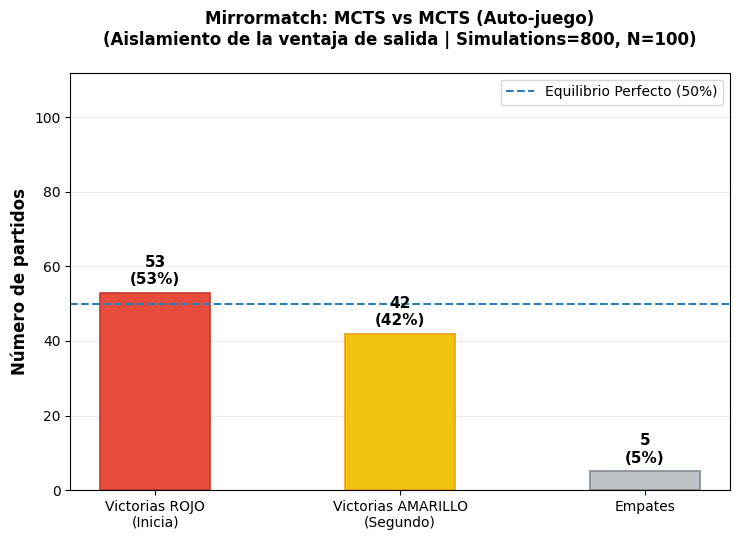

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

Matches = 100
Simulations = 800

class MirrorTelemetryMCTS(MCTS):
    bitacora_juegos = []
    fichas_totales_juego = 0

    def mount(self, action_timeout=None):
        if MirrorTelemetryMCTS.fichas_totales_juego > 0:
            MirrorTelemetryMCTS.bitacora_juegos.append(MirrorTelemetryMCTS.fichas_totales_juego)
        MirrorTelemetryMCTS.fichas_totales_juego = 0
        super().mount(action_timeout)

    def act(self, state_or_board):
        MirrorTelemetryMCTS.fichas_totales_juego += 1
        return super().act(state_or_board)

print(f"--- Iniciando MirrorMatch: MCTS vs MCTS (N={Matches} | Simulations={Simulations}) ---")

wins_red, wins_yellow, draws = run_series(
    MirrorTelemetryMCTS, MirrorTelemetryMCTS, Matches, 
    parameters_a={'n_simulations': Simulations},
    parameters_b={'n_simulations': Simulations}
)

if MirrorTelemetryMCTS.fichas_totales_juego > 0:
    MirrorTelemetryMCTS.bitacora_juegos.append(MirrorTelemetryMCTS.fichas_totales_juego)

print(f"\nResultados del Auto-juego -> Victorias ROJO: {wins_red} | Victorias AMARILLO: {wins_yellow} | Empates: {draws}")

# =====================================================================
# Reporte de Insights
# =====================================================================
print("\n" + "="*50)
print("Métricas de Enfrentamiento")
print("="*50)
avg_fichas = np.mean(MirrorTelemetryMCTS.bitacora_juegos) if MirrorTelemetryMCTS.bitacora_juegos else 0
max_fichas = np.max(MirrorTelemetryMCTS.bitacora_juegos) if MirrorTelemetryMCTS.bitacora_juegos else 0
min_fichas = np.min(MirrorTelemetryMCTS.bitacora_juegos) if MirrorTelemetryMCTS.bitacora_juegos else 0

print(f" Total de fichas promedio por partida: {avg_fichas:.1f} movimientos.")
print(f" Partida más larga y disputada: {max_fichas} fichas en tablero.")
print(f" Partida más fulminante: {min_fichas} fichas en tablero.")
print("="*50 + "\n")

# =====================================================================
# Gráfica de Rendimiento
# =====================================================================
fig, ax = plt.subplots(figsize=(7.5, 5.5))

categorias = ['Victorias ROJO\n(Inicia)', 'Victorias AMARILLO\n(Segundo)', 'Empates']
valores = [wins_red, wins_yellow, draws]
colores = ['#e74c3c', '#f1c40f', '#bdc3c7']
bordes = ['#c0392b', '#f39c12', '#7f8c8d']

bars = ax.bar(categorias, valores, color=colores, edgecolor=bordes, lw=1.2, width=0.45)

for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, 
            f'{v}\n({v/Matches:.0%})', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(Matches * 0.5, color='#2980b9', ls='--', lw=1.5, label='Equilibrio Perfecto (50%)')

ax.set_ylim(0, Matches + 12)
ax.set_ylabel('Número de partidos', fontsize=12, fontweight='bold')
ax.set_title(f'Mirrormatch: MCTS vs MCTS (Auto-juego)\n(Aislamiento de la ventaja de salida | Simulations={Simulations}, N={Matches})', 
             fontsize=12, fontweight='bold', pad=20)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()

os.makedirs('groups/MCTS', exist_ok=True)
plt.savefig('groups/MCTS/fig_mirror_match.png', dpi=140, bbox_inches='tight')
plt.show()

Al enfrentar al agente MCTS contra su réplica exacta bajo un presupuesto de 800 simulaciones, el experimento de mirrormatch logra aislar la ventaja del primer movimiento del Connect-4. Los resultados revelan una distribución del 53% de victorias para el jugador rojo frente a un 42% para el amarillo, acompañados por un 5% de empates. Dado que ambos contendientes comparten exactamente la misma arquitectura, este diferencial del 11% demuestra empíricamente que la iniciativa de la primera jugada otorga una ventaja posicional estructural un árbol altamente expandido de 800 simulaciones no puede neutralizar por completo.

El promedio de 32.9 movimientos por partida confirma que los errores y los descuidos de corto alcance practicamente no aparecen, forzando a los agentes a trabarse en disputas de desgaste que arrastran la resolución hasta las fases más tardías del tablero. Por el contrario, el escenario de 15 fichas en total pone de manifiesto que, incluso con 800 simulaciones, la natural dispersión horizontal en la apertura impuesta por la constante de exploración ($c = \sqrt{2}$) puede abrir una ventana de vulnerabilidad en los primeros turnos; una vez que el jugador rojo logra encajar una secuencia ofensiva optimizada en ese espacio, la simetría se rompe de forma tan prematura que el defensor amarillo se vuelve incapaz de recalcular una salida viable dentro de su horizonte de búsqueda.

## 3. Propuestas de Mejora

A partir de los cuellos de botella identificados en la telemetría, se proponen dos líneas de desarrollo para una evolución del agente:

### 3.1 Implementación de un Libro de Aperturas Heurístico
Una mejora de bajo costo y alto impacto es la inclusión de un *Libro de Aperturas*. Forzar al agente a jugar matemáticamente en la columna central durante los primeros dos movimientos propios ahorraría el 100% del presupuesto de simulaciones en la fase de apertura, reservando esa potencia de cómputo exclusivamente para los turnos críticos del juego medio y tardío, donde las horquillas del rival representan un peligro real.

### 3.2 Sustitución de Rollouts por Redes de Política-Valor (Arquitectura SL-MCTS)
La mayor ineficiencia del MCTS base radica en la fase de simulación, la cual ejecuta movimientos aleatorios hasta el final de la partida para obtener una recompensa, diluyendo el presupuesto de cómputo. Se propone sustituir por completo los rollouts por una red neuronal de dos ramas. 

Esta red aproximará simultáneamente la dirección de búsqueda más prometedora, con una Política, y el valor del estado del tablero. Al truncar la profundidad de las simulaciones y guiar el árbol con este conocimiento previo, se incrementa drásticamente la velocidad de convergencia.

https://www.frontiersin.org/journals/neurorobotics/articles/10.3389/fnbot.2023.1039644/full